# Experiment 3.0.1 — Single-$\tau_{syn}$ × objective comparison

## Formal protocol: `paired_split_v2`

At a fixed 3-layer feature SNN, which homogeneous synaptic time scale is best, and does the answer depend on the training objective?

Backbone: `30 -> 128 -> 128 -> 64`, no recurrence, no bias in the three SNN Linear layers. L1/L2/L3 use the same `shift_syn` within one run. Shifts: `[2, 3, 4, 5, 6, 7]`.

Objectives:
- `timestep_ce`: shared `64 -> 12` classifier at every valid timestep; CE averaged over valid timesteps.
- `relative10_sequence_ce`: valid gesture divided into 10 relative-progress bins; L3 spike counts are flattened and classified once per segment.
- `fixed250_sequence_ce`: valid-masked fixed 250 ms bins (16 samples at 64 Hz); L3 spike counts are flattened and classified once per segment. SNN state is continuous across bin boundaries.

Grid: `6 shifts × 3 objectives × 3 seeds = 54 runs`, seeds `(11, 23, 101)`, fixed split seed `12345`.

### `paired_split_v2` controls
- user split exactly matches the existing Phase-B / Experiment-3.0 rule: direct `default_rng(12345)`, sorted users, floor train/validation fractions;
- for a given master seed, every shift and every objective receives identical initial SNN backbone weights;
- objective-specific heads are initialized deterministically after the paired backbone;
- checkpoints carry and validate protocol, split, architecture, and training provenance;
- firing rates use total valid spikes divided by total valid neuron-timesteps;
- zero-input firing is measured without invoking classification metrics.

Formal training is performed by `scripts/bash_script/SNN_Bash/run_exp_3_0_1_cpu_array.bash`. This notebook is analysis-only. Earlier root-level Experiment 3.0.1 artifacts are pilot results and are intentionally not loaded here.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('writingRing repository root not found')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.experiment_3_0_1_single_tau_objectives import (
    EXPERIMENT_ID, PROTOCOL_VERSION, EXPECTED_RUNS,
    SHIFTS, OBJECTIVES, SEEDS, WIDTHS, protocol_results_dir,
)

RESULTS_DIR = protocol_results_dir(REPO_ROOT)
RESULTS_PATH = RESULTS_DIR / 'experiment_3_0_1_results.csv'
HISTORY_PATH = RESULTS_DIR / 'experiment_3_0_1_history.csv'
SUMMARY_PATH = RESULTS_DIR / 'experiment_3_0_1_summary.csv'

for path in (RESULTS_PATH, HISTORY_PATH, SUMMARY_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f'Formal {PROTOCOL_VERSION} artifact missing: {path}. '
            'Run the Slurm array and finalizer first.'
        )

RESULTS = pd.read_csv(RESULTS_PATH)
HISTORY = pd.read_csv(HISTORY_PATH)
SUMMARY = pd.read_csv(SUMMARY_PATH)

if len(RESULTS) != EXPECTED_RUNS:
    raise RuntimeError(f'Expected {EXPECTED_RUNS} runs, found {len(RESULTS)}')
if set(RESULTS.protocol_version.unique()) != {PROTOCOL_VERSION}:
    raise RuntimeError('Results contain the wrong protocol version')

print('Repository root:', REPO_ROOT)
print('Experiment:', EXPERIMENT_ID)
print('Protocol:', PROTOCOL_VERSION)
print('Results dir:', RESULTS_DIR.relative_to(REPO_ROOT))
print('Widths:', WIDTHS)
print('Shifts:', SHIFTS)
print('Objectives:', OBJECTIVES)
print('Seeds:', SEEDS)
print('Completed runs:', len(RESULTS), '/', EXPECTED_RUNS)
display(SUMMARY)

Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
Experiment: experiment_3_0_1_single_tau_objective_comparison
Protocol: paired_split_v2
Results dir: notebooks/artifacts/experiment_3_0_1_single_tau_objective_comparison/paired_split_v2
Widths: (128, 128, 64)
Shifts: (2, 3, 4, 5, 6, 7)
Objectives: ('timestep_ce', 'relative10_sequence_ce', 'fixed250_sequence_ce')
Seeds: (11, 23, 101)
Completed runs: 54 / 54


,objective,shift,tau_syn_ms,mean_test_balanced_accuracy,mean_test_macro_f1,mean_test_accuracy,mean_probe_test_balanced_accuracy,mean_probe_test_macro_f1,mean_val_balanced_accuracy,mean_train_test_ba_gap,...,sd_test_macro_f1,sd_test_accuracy,sd_probe_test_balanced_accuracy,sd_probe_test_macro_f1,sd_val_balanced_accuracy,sd_train_test_ba_gap,sd_best_epoch,sd_test_l1_firing_rate,sd_test_l2_firing_rate,sd_test_l3_firing_rate
0,fixed250_sequence_ce,2,54.313430,0.357745,0.336164,0.365297,0.364157,0.346041,0.408409,0.536050,...,0.052980,0.053202,0.034001,0.041310,0.067268,0.033058,2.081666,0.000244,0.001161,0.009825
1,fixed250_sequence_ce,3,117.013683,0.453162,0.447141,0.465753,0.525037,0.514092,0.497657,0.486341,...,0.005369,0.013699,0.036430,0.034923,0.046088,0.053469,22.744963,0.001743,0.012488,0.048259
2,fixed250_sequence_ce,4,242.103471,0.427551,0.416935,0.436073,0.409677,0.411497,0.455101,0.545796,...,0.033286,0.027681,0.024198,0.030532,0.020627,0.029183,7.549834,0.002866,0.014561,0.001415
3,fixed250_sequence_ce,5,492.146161,0.294204,0.301037,0.296804,0.317163,0.321597,0.329604,0.677651,...,0.016210,0.017237,0.022216,0.026914,0.013133,0.028541,21.656408,0.003703,0.016863,0.009510
4,fixed250_sequence_ce,6,992.166994,0.246520,0.246720,0.248858,0.270629,0.277866,0.344234,0.751866,...,0.021811,0.024054,0.041919,0.035072,0.054935,0.023844,18.583146,0.004053,0.014506,0.021536
5,fixed250_sequence_ce,7,1992.177288,0.230917,0.230819,0.235160,0.229016,0.234226,0.303417,0.767480,...,0.008891,0.014258,0.041102,0.047160,0.016145,0.013050,19.035055,0.002742,0.011865,0.015146
6,relative10_sequence_ce,2,54.313430,0.513918,0.508838,0.518265,0.402063,0.392535,0.560660,0.378650,...,0.053385,0.045605,0.025100,0.024578,0.026229,0.032897,15.373137,0.001794,0.018173,0.027836
7,relative10_sequence_ce,3,117.013683,0.568385,0.570236,0.573059,0.529129,0.533333,0.603882,0.405412,...,0.025927,0.033787,0.042170,0.052715,0.021847,0.036364,11.532563,0.001487,0.008784,0.015654
8,relative10_sequence_ce,4,242.103471,0.511985,0.512550,0.513699,0.459122,0.461819,0.520262,0.450674,...,0.008452,0.013699,0.030274,0.022510,0.014599,0.010903,14.571662,0.000916,0.005745,0.004926
9,relative10_sequence_ce,5,492.146161,0.341197,0.341685,0.344749,0.307865,0.302101,0.365194,0.634757,...,0.013293,0.022017,0.003574,0.016683,0.056834,0.013892,10.598742,0.003575,0.008039,0.004521


## 1. Per-run results

In [2]:
display(RESULTS.sort_values(['objective', 'shift', 'seed']))

,protocol_version,shift,tau_syn_ms,objective,seed,best_epoch,probe_C,probe_val_balanced_accuracy,probe_test_balanced_accuracy,probe_test_macro_f1,...,test_accuracy,test_balanced_accuracy,test_macro_f1,train_test_ba_gap,test_l1_firing_rate,zero_l1_firing_rate,test_l2_firing_rate,zero_l2_firing_rate,test_l3_firing_rate,zero_l3_firing_rate
0,paired_split_v2,2,54.313430,fixed250_sequence_ce,11,97,0.100,0.389881,0.383541,0.375060,...,0.349315,0.339992,0.331140,0.552084,0.006845,0.0,0.050805,0.0,0.138048,0.0
1,paired_split_v2,2,54.313430,fixed250_sequence_ce,23,96,0.010,0.385161,0.324897,0.298746,...,0.321918,0.322793,0.285875,0.558033,0.006558,0.0,0.048891,0.0,0.118433,0.0
2,paired_split_v2,2,54.313430,fixed250_sequence_ce,101,100,0.100,0.468200,0.384033,0.364318,...,0.424658,0.410449,0.391478,0.498033,0.007043,0.0,0.048710,0.0,0.127231,0.0
3,paired_split_v2,3,117.013683,fixed250_sequence_ce,11,75,0.010,0.458303,0.531550,0.525009,...,0.465753,0.450270,0.446133,0.526616,0.013058,0.0,0.080722,0.0,0.202776,0.0
4,paired_split_v2,3,117.013683,fixed250_sequence_ce,23,43,0.100,0.443915,0.485790,0.475015,...,0.452055,0.447552,0.442348,0.425676,0.010372,0.0,0.058479,0.0,0.149720,0.0
5,paired_split_v2,3,117.013683,fixed250_sequence_ce,101,87,0.010,0.525896,0.557771,0.542253,...,0.479452,0.461663,0.452943,0.506729,0.013640,0.0,0.079438,0.0,0.246073,0.0
6,paired_split_v2,4,242.103471,fixed250_sequence_ce,11,89,0.100,0.444126,0.408549,0.417675,...,0.431507,0.424918,0.427347,0.555595,0.020351,0.0,0.110999,0.0,0.221130,0.0
7,paired_split_v2,4,242.103471,fixed250_sequence_ce,23,80,10.000,0.414226,0.434419,0.438468,...,0.465753,0.447677,0.443771,0.512974,0.014971,0.0,0.082762,0.0,0.218974,0.0
8,paired_split_v2,4,242.103471,fixed250_sequence_ce,101,95,1.000,0.462969,0.386063,0.378349,...,0.410959,0.410058,0.379689,0.568818,0.019373,0.0,0.103051,0.0,0.221640,0.0
9,paired_split_v2,5,492.146161,fixed250_sequence_ce,11,62,0.010,0.325108,0.298446,0.301646,...,0.280822,0.273773,0.282733,0.705654,0.032085,0.0,0.192807,0.0,0.273612,0.0


## 2. Native test balanced accuracy vs. shift

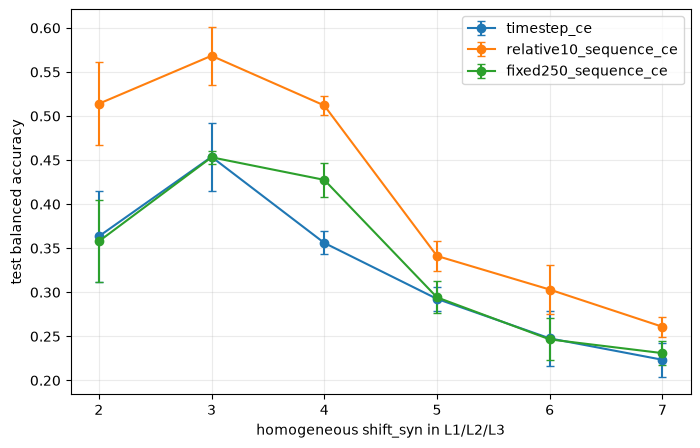

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for objective in OBJECTIVES:
    part = SUMMARY[SUMMARY.objective == objective].sort_values('shift')
    ax.errorbar(
        part['shift'], part['mean_test_balanced_accuracy'],
        yerr=part['sd_test_balanced_accuracy'],
        marker='o', capsize=3, label=objective,
    )
ax.set(
    xlabel='homogeneous shift_syn in L1/L2/L3',
    ylabel='test balanced accuracy',
    xticks=SHIFTS,
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 3. Common fixed-250-ms frozen linear-probe BA

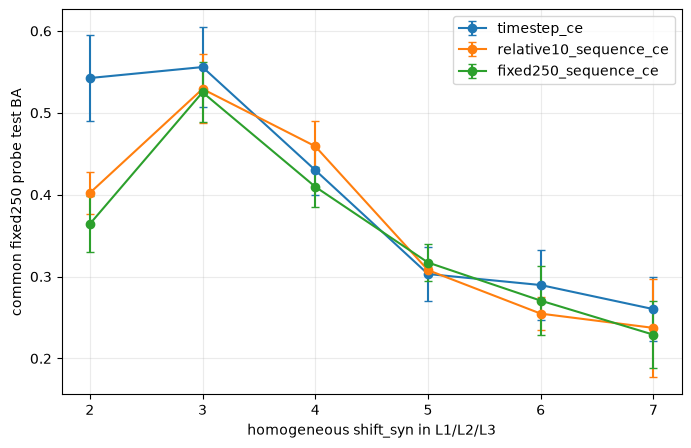

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for objective in OBJECTIVES:
    part = SUMMARY[SUMMARY.objective == objective].sort_values('shift')
    ax.errorbar(
        part['shift'], part['mean_probe_test_balanced_accuracy'],
        yerr=part['sd_probe_test_balanced_accuracy'],
        marker='o', capsize=3, label=objective,
    )
ax.set(
    xlabel='homogeneous shift_syn in L1/L2/L3',
    ylabel='common fixed250 probe test BA',
    xticks=SHIFTS,
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 4. Validation BA vs. epoch

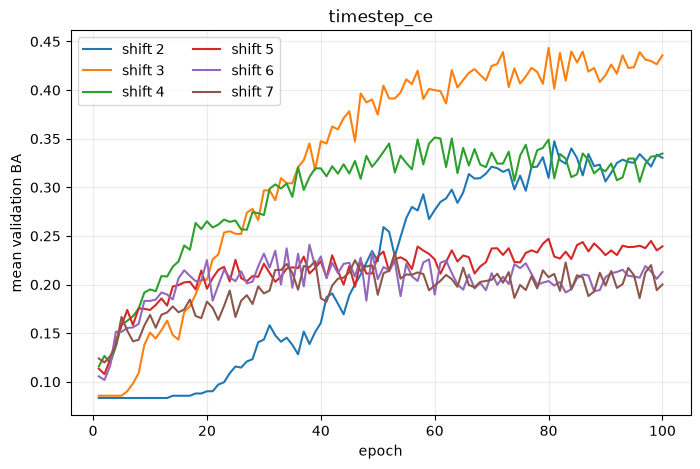

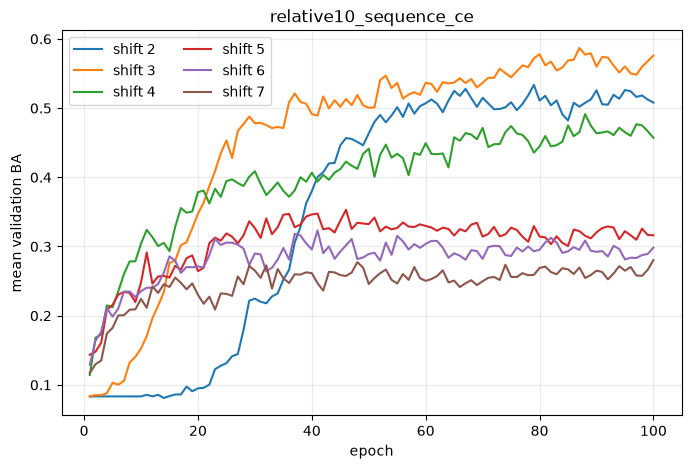

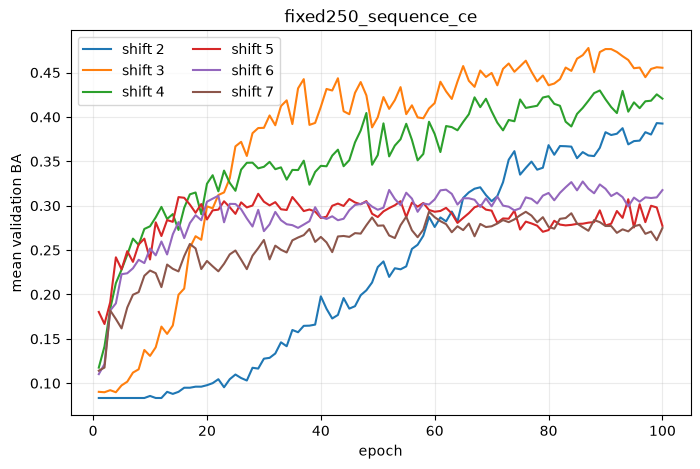

In [5]:
mean_history = (
    HISTORY.groupby(['objective', 'shift', 'epoch'], as_index=False)
    .val_balanced_accuracy.mean()
)
for objective in OBJECTIVES:
    fig, ax = plt.subplots(figsize=(8, 5))
    part = mean_history[mean_history.objective == objective]
    for shift in SHIFTS:
        curve = part[part['shift'] == shift]
        ax.plot(curve.epoch, curve.val_balanced_accuracy, label=f'shift {shift}')
    ax.set(title=objective, xlabel='epoch', ylabel='mean validation BA')
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.show()

## 5. Firing-rate diagnostics

,objective,shift,seed,test_l1_firing_rate,test_l2_firing_rate,test_l3_firing_rate,zero_l1_firing_rate,zero_l2_firing_rate,zero_l3_firing_rate
0,fixed250_sequence_ce,2,11,0.006845,0.050805,0.138048,0.0,0.0,0.0
1,fixed250_sequence_ce,2,23,0.006558,0.048891,0.118433,0.0,0.0,0.0
2,fixed250_sequence_ce,2,101,0.007043,0.048710,0.127231,0.0,0.0,0.0
3,fixed250_sequence_ce,3,11,0.013058,0.080722,0.202776,0.0,0.0,0.0
4,fixed250_sequence_ce,3,23,0.010372,0.058479,0.149720,0.0,0.0,0.0
5,fixed250_sequence_ce,3,101,0.013640,0.079438,0.246073,0.0,0.0,0.0
6,fixed250_sequence_ce,4,11,0.020351,0.110999,0.221130,0.0,0.0,0.0
7,fixed250_sequence_ce,4,23,0.014971,0.082762,0.218974,0.0,0.0,0.0
8,fixed250_sequence_ce,4,101,0.019373,0.103051,0.221640,0.0,0.0,0.0
9,fixed250_sequence_ce,5,11,0.032085,0.192807,0.273612,0.0,0.0,0.0


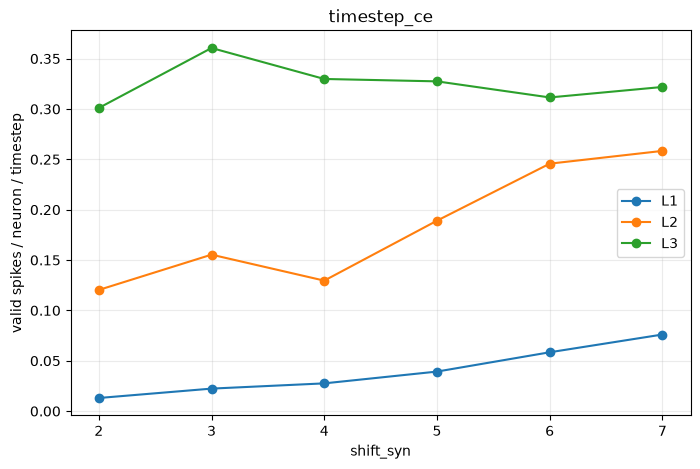

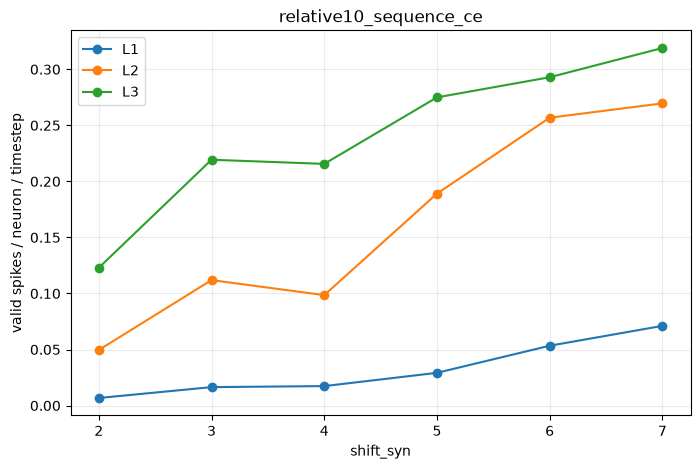

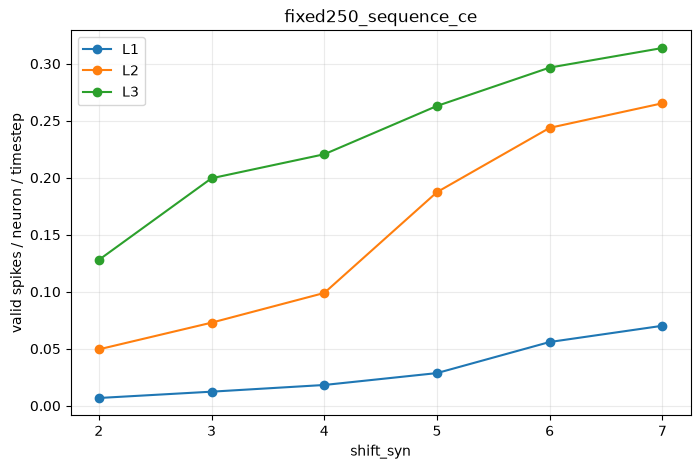

In [6]:
fr_cols = [
    'objective', 'shift', 'seed',
    'test_l1_firing_rate', 'test_l2_firing_rate', 'test_l3_firing_rate',
    'zero_l1_firing_rate', 'zero_l2_firing_rate', 'zero_l3_firing_rate',
]
display(RESULTS[fr_cols])

for objective in OBJECTIVES:
    fig, ax = plt.subplots(figsize=(8, 5))
    part = (
        RESULTS[RESULTS.objective == objective]
        .groupby('shift', as_index=False)[
            ['test_l1_firing_rate','test_l2_firing_rate','test_l3_firing_rate']
        ].mean()
    )
    for column, label in [
        ('test_l1_firing_rate', 'L1'),
        ('test_l2_firing_rate', 'L2'),
        ('test_l3_firing_rate', 'L3'),
    ]:
        ax.plot(part['shift'], part[column], marker='o', label=label)
    ax.set(
        title=objective, xlabel='shift_syn',
        ylabel='valid spikes / neuron / timestep', xticks=SHIFTS,
    )
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

## 6. Generalization gap and checkpoint epoch

In [7]:
display(
    SUMMARY[[
        'objective', 'shift', 'tau_syn_ms',
        'mean_train_test_ba_gap', 'sd_train_test_ba_gap',
        'mean_best_epoch', 'sd_best_epoch',
    ]].sort_values(['objective', 'shift'])
)

,objective,shift,tau_syn_ms,mean_train_test_ba_gap,sd_train_test_ba_gap,mean_best_epoch,sd_best_epoch
0,fixed250_sequence_ce,2,54.313430,0.536050,0.033058,97.666667,2.081666
1,fixed250_sequence_ce,3,117.013683,0.486341,0.053469,68.333333,22.744963
2,fixed250_sequence_ce,4,242.103471,0.545796,0.029183,88.000000,7.549834
3,fixed250_sequence_ce,5,492.146161,0.677651,0.028541,42.000000,21.656408
4,fixed250_sequence_ce,6,992.166994,0.751866,0.023844,76.333333,18.583146
5,fixed250_sequence_ce,7,1992.177288,0.767480,0.013050,57.666667,19.035055
6,relative10_sequence_ce,2,54.313430,0.378650,0.032897,77.333333,15.373137
7,relative10_sequence_ce,3,117.013683,0.405412,0.036364,88.000000,11.532563
8,relative10_sequence_ce,4,242.103471,0.450674,0.010903,76.333333,14.571662
9,relative10_sequence_ce,5,492.146161,0.634757,0.013892,39.333333,10.598742


## 7. Rankings

In [8]:
native = (
    RESULTS.groupby(['objective','shift']).test_balanced_accuracy
    .agg(['mean','std']).sort_values('mean', ascending=False)
)
probe = (
    RESULTS.groupby(['objective','shift']).probe_test_balanced_accuracy
    .agg(['mean','std']).sort_values('mean', ascending=False)
)
print('Native head ranking')
display(native)
print('Common frozen-probe ranking')
display(probe)

Native head ranking


mean       std
objective              shift                    
relative10_sequence_ce 3      0.568385  0.032652
                       2      0.513918  0.047271
                       4      0.511985  0.010870
timestep_ce            3      0.453668  0.038418
fixed250_sequence_ce   3      0.453162  0.007486
                       4      0.427551  0.018947
timestep_ce            2      0.363406  0.051562
fixed250_sequence_ce   2      0.357745  0.046446
timestep_ce            4      0.356013  0.013068
relative10_sequence_ce 5      0.341197  0.017532
                       6      0.303071  0.028273
fixed250_sequence_ce   5      0.294204  0.018194
timestep_ce            5      0.292474  0.014050
relative10_sequence_ce 7      0.260849  0.011562
timestep_ce            6      0.247668  0.031242
fixed250_sequence_ce   6      0.246520  0.023874
                       7      0.230917  0.013587
timestep_ce            7      0.223395  0.019564

Common frozen-probe ranking


mean       std
objective              shift                    
timestep_ce            3      0.555879  0.048933
                       2      0.542482  0.052559
relative10_sequence_ce 3      0.529129  0.042170
fixed250_sequence_ce   3      0.525037  0.036430
relative10_sequence_ce 4      0.459122  0.030274
timestep_ce            4      0.430002  0.030596
fixed250_sequence_ce   4      0.409677  0.024198
relative10_sequence_ce 2      0.402063  0.025100
fixed250_sequence_ce   2      0.364157  0.034001
                       5      0.317163  0.022216
relative10_sequence_ce 5      0.307865  0.003574
timestep_ce            5      0.303127  0.032828
                       6      0.289658  0.042609
fixed250_sequence_ce   6      0.270629  0.041919
timestep_ce            7      0.260232  0.038773
relative10_sequence_ce 6      0.254742  0.020362
                       7      0.237328  0.059979
fixed250_sequence_ce   7      0.229016  0.041102

## Interpretation
Use the 3-seed mean and SD, not one seed. First ask whether a consistent single-$\tau$ optimum exists. Then ask whether the optimum changes with supervision. Agreement between native-head BA and the common fixed250 probe supports a representation-level effect; disagreement suggests the objective-specific head/readout contributes materially. Inspect firing rates and the train-test gap before carrying a single-$\tau$ baseline into the multi-$\tau$ architecture study.